In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from itertools import combinations
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
# Load data
df = pd.read_csv("train.csv")

## Item Price Min and Max

In [3]:
df["item_price_min"].min(), df["item_price_min"].max()

(100000, 1660000000)

In [4]:
df["item_price_max"].min(), df["item_price_max"].max()

(100000, 1660000000)

In [5]:
# normalize price min-max
df["item_price_min"] = df["item_price_min"] / 100000
df["item_price_max"] = df["item_price_max"] / 100000

In [6]:
def plot_correlation_matrix(
    df,
    columns=None,
    method="pearson",
    figsize=(5, 4),
    cmap="coolwarm",
    annot=True,
):
    if columns is None:
        columns = [
            "price",
            "item_price_min",
            "item_price_max",
        ]

    corr = df[columns].corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=annot,
        fmt=".2f",
        cmap=cmap,
        vmin=-1,
        vmax=1,
        square=True,
    )

    plt.title(f"{method.capitalize()} Correlation Matrix")
    plt.tight_layout()
    plt.show()

    return corr

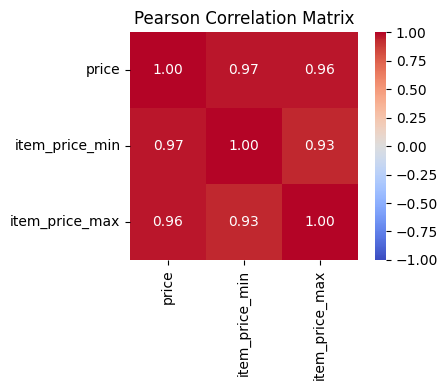

In [7]:
corr = plot_correlation_matrix(
    df,
    columns=["price", "item_price_min", "item_price_max"],
    method="pearson",
)

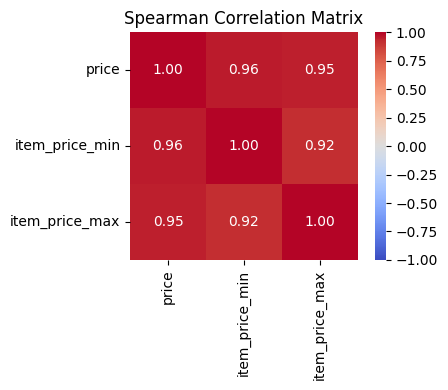

In [8]:
corr = plot_correlation_matrix(
    df,
    columns=["price", "item_price_min", "item_price_max"],
    method="spearman",
)

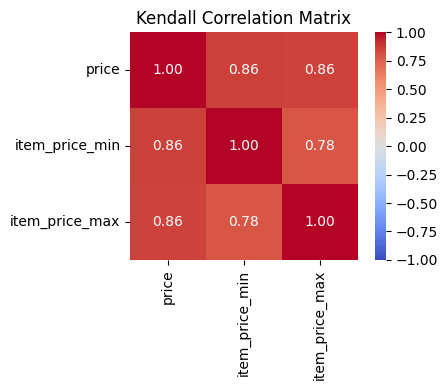

In [9]:
corr = plot_correlation_matrix(
    df,
    columns=["price", "item_price_min", "item_price_max"],
    method="kendall",
)

## Others

In [10]:
df['is_free_shipping'].value_counts()

is_free_shipping
f    289629
t     16597
Name: count, dtype: int64

In [11]:
df['is_pre_order'].value_counts()

is_pre_order
f    284813
t     21413
Name: count, dtype: int64

In [12]:
df['review_rating'].describe()

count    306226.000000
mean          4.657069
std           1.178862
min           0.000000
25%           4.937500
50%           4.985000
75%           5.000000
max           5.000000
Name: review_rating, dtype: float64

In [13]:
df['total_rating_count'].describe()

count    306226.000000
mean         92.299609
std         319.878155
min           0.000000
25%           4.000000
50%          16.000000
75%          64.000000
max       15462.000000
Name: total_rating_count, dtype: float64

In [14]:
df['cmt_count'].describe()

count    306226.000000
mean         87.292986
std         311.354822
min           0.000000
25%           4.000000
50%          15.000000
75%          57.000000
max       15309.000000
Name: cmt_count, dtype: float64

In [15]:
cols = [
    "price",
    "review_rating",
    "total_rating_count",
    "cmt_count",
]

corr = (
    df[cols]
    .corr(method="pearson")
    .loc[
        ["review_rating", "total_rating_count", "cmt_count"],
        ["price"],
    ]
    .rename(columns={"price": "pearson_corr_with_price"})
)

In [16]:
corr

,pearson_corr_with_price
review_rating,-0.118075
total_rating_count,-0.081521
cmt_count,-0.078024
